In [1]:
# 1. Configurazione Iniziale
import os
from DataLoader import BCIAUTLoader, plot_normalized_arrays
from complexity_metrics import calculate_complexity_metrics
from Oversampling import apply_smote_3d
from classifiers import run_p300_classification, classify_eeg, EEGNetModel, TrainModel, EvalModel
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
import numpy as np
import torch
# Ottieni il percorso assoluto della cartella in cui si trova questo script (main.py)
project_root = os.getcwd()

# Costruisci il percorso verso la cartella data
# IMPORTANTE: Cambia 'bciaut' con il nome esatto della cartella che hai dentro 'data'
dataset_path = os.path.join(project_root, 'data') 

print(f"Percorso base rilevato: {dataset_path}")

# Istanzia il loader con il nuovo percorso
loader = BCIAUTLoader(dataset_path)
# --- SCENARIO A: Cross-Session (Stesso Soggetto) ---
# Addestramento su sessioni 1-5, Test su sessioni 6-7 (Soggetto 3)
print("\n--- SCENARIO A: Cross-Session (Soggetto 3) ---")
X_train_sess, y_train_sess, subjects_train_ids, session_train_ids = loader.get_data(subjects=[3], sessions=[3], modes=['Train'])
X_test_sess, y_test_sess, subjects_test_ids, session_test_ids   = loader.get_data(subjects=[3], sessions=[3], modes=['Test'])

#X_train_sess, X_test_sess = loader.normalize_data_z_score(X_train_sess, X_test_sess)
#X_train_sess, X_test_sess = loader.normalize_data_minmax(X_train_sess, X_test_sess)
# --- SCENARIO B: Cross-Subject (Leave-One-Out) ---
# Addestramento su Soggetti 1-14, Test su Soggetto 15 (Tutte le sessioni)
print("\n--- SCENARIO B: Cross-Subject (Train: 1-14, Test: 15) ---")
#train_subjects = list(range(1, 15)) # [1, ..., 14]
#test_subjects = [15]

# Nota: modes=['Train', 'Test'] unisce i dati di training e testing originali per avere più dati
#X_train_subj, y_train_subj = loader.get_data(subjects=train_subjects, sessions='all', modes=['Train', 'Test'])
#X_test_subj, y_test_subj   = loader.get_data(subjects=test_subjects, sessions='all', modes=['Train', 'Test'])

#X_train_subj, X_test_subj = loader.normalize_data(X_train_subj, X_test_subj)

print(f"\nDataset Cross-Subject pronto:")
print(f"X_train shape: {X_train_sess.shape}")
print(f"X_test shape: {X_test_sess.shape}")

Percorso base rilevato: /home/giorgio99/gan_bci/EEG-synthetic/data

--- SCENARIO A: Cross-Session (Soggetto 3) ---
Caricamento Soggetti: [3], Sessioni: [3], Modalità: ['Train']


/home/giorgio99/gan_bci/EEG-synthetic/DataLoader.py:79: RuntimeWarning: filter_length (8251) is longer than the signal (350), distortion is likely. Reduce filter length or filter a longer signal.
  epochs.filter(l_freq=0.1, h_freq=15.0, fir_design='firwin', verbose=False)


-> Totale caricato: (1600, 8, 128) - Classi: (array([0, 1]), array([1400,  200]))
Caricamento Soggetti: [3], Sessioni: [3], Modalità: ['Test']


/home/giorgio99/gan_bci/EEG-synthetic/DataLoader.py:79: RuntimeWarning: filter_length (8251) is longer than the signal (350), distortion is likely. Reduce filter length or filter a longer signal.
  epochs.filter(l_freq=0.1, h_freq=15.0, fir_design='firwin', verbose=False)


-> Totale caricato: (2800, 8, 128) - Classi: (array([0, 1]), array([2450,  350]))

--- SCENARIO B: Cross-Subject (Train: 1-14, Test: 15) ---

Dataset Cross-Subject pronto:
X_train shape: (1600, 8, 128)
X_test shape: (2800, 8, 128)


In [2]:
if isinstance(y_train_sess, np.ndarray):
    classes, counts = np.unique(y_train_sess, return_counts=True)
else:
    classes, counts = torch.unique(y_train_sess, return_counts=True)
    classes, counts = classes.cpu().numpy(), counts.cpu().numpy()

print(f"X_train shape: {X_train_sess.shape}")
print("-" * 35)
for cls, count in zip(classes, counts):
    label = "Win (0)" if cls == 0 else "Loss (1)"
    print(f"Classe {int(cls)} [{label}]: {count} trial")

# Calcolo dello sbilanciamento in percentuale
total = counts.sum()
perc_0 = (counts[0] / total) * 100
perc_1 = (counts[1] / total) * 100
print("-" * 35)
print(f"Distribuzione: {perc_0:.2f}% (Win) vs {perc_1:.2f}% (Loss)")

X_train shape: (1600, 8, 128)
-----------------------------------
Classe 0 [Win (0)]: 1400 trial
Classe 1 [Loss (1)]: 200 trial
-----------------------------------
Distribuzione: 87.50% (Win) vs 12.50% (Loss)


--- Generazione Grafici NumPy ---


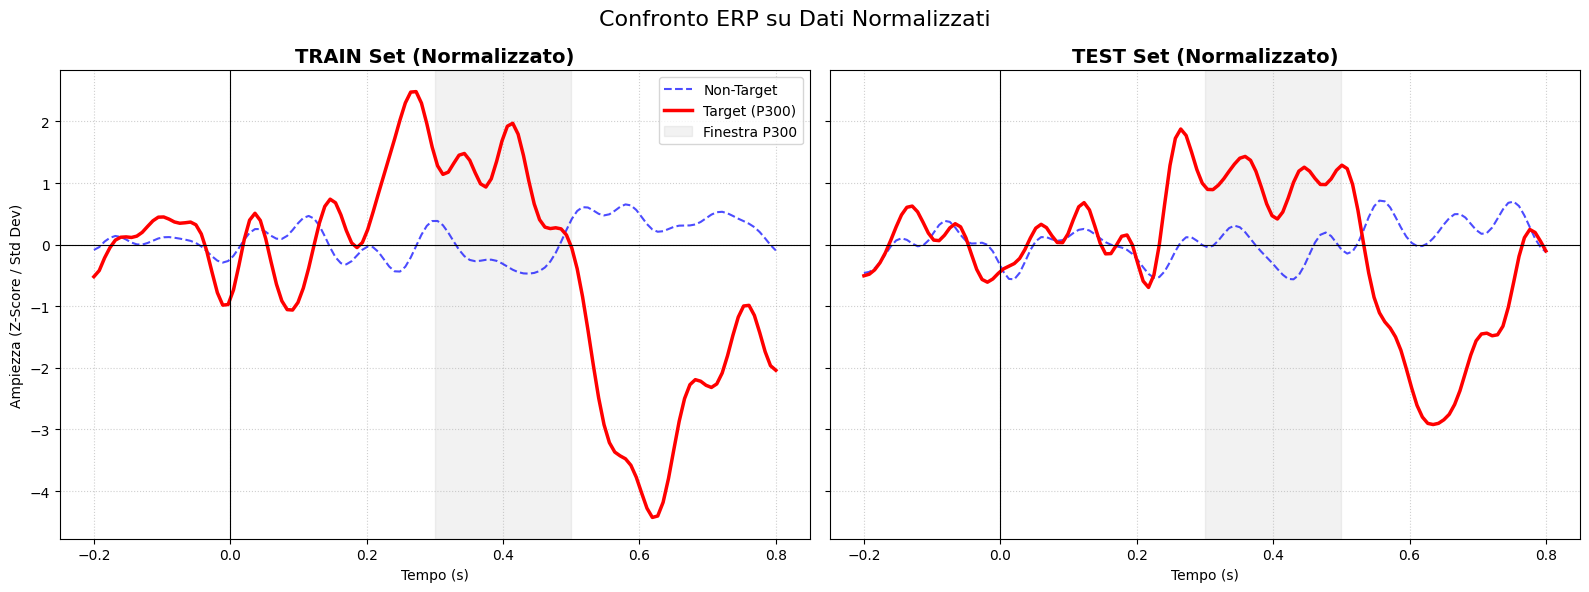

In [3]:
plot_normalized_arrays(X_train_sess, y_train_sess, X_test_sess, y_test_sess)

--- Calcolo Complessità | Metodo: PCA ---
Strategia: PCA (Comp: 50)
Dataset ridotto per complessità: (16, 50)
Calcolo metriche in corso...
Calcolo completato.
Visualizzazione PCA:
{'feature': {}, 'struct': {'N1': 0.1875, 'N2': 0.48471438555992813}, 'instance': {'kDN': 0.25, 'N3': 0.1875, 'N4': 0.0}, 'multi': {'C1': 0.25520833333333337, 'C2': 1.0}}


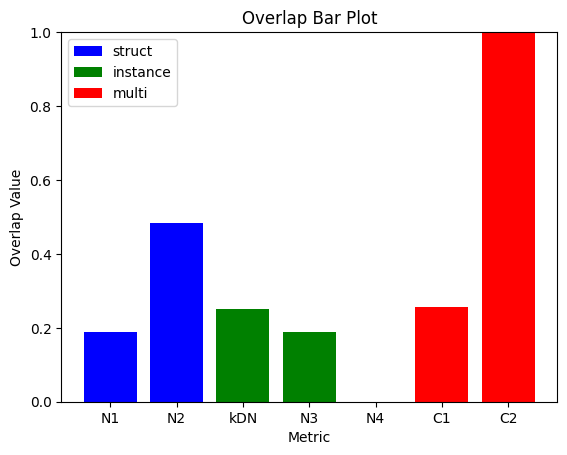

--- Calcolo Complessità | Metodo: SPATIAL ---
Strategia: Media Spaziale (Tutti i canali)
Dataset ridotto per complessità: (16, 128)
Calcolo metriche in corso...
Calcolo completato.

Visualizzazione Spatial Mean:
{'feature': {}, 'struct': {'N1': 0.375, 'N2': 0.45659246491886435}, 'instance': {'kDN': 0.25, 'N3': 0.1875, 'N4': 0.0}, 'multi': {'C1': 0.22083333333333333, 'C2': 1.0}}


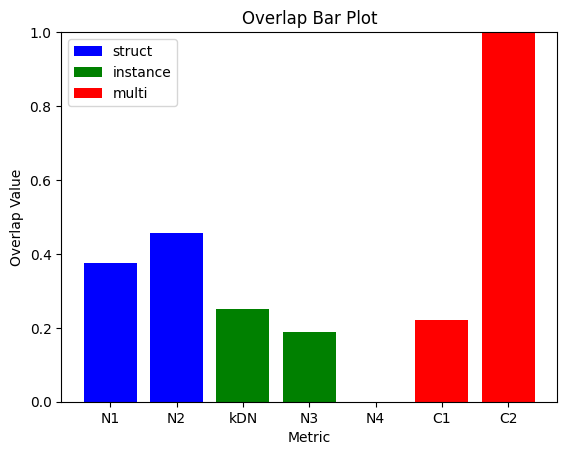

In [4]:
# ESEMPIO 1: Metodo PCA (come facevi prima)
comp_pca = calculate_complexity_metrics(
    X_train_sess, y_train_sess, 
    method='pca', 
    n_components=50, 
    subset_ratio=0.01, imb=False
)
print("Visualizzazione PCA:")
comp_pca.viz_metrics(imb=False)


# ESEMPIO 2: Metodo Spatial (Media di tutti i canali)
comp_spatial_mean = calculate_complexity_metrics(
    X_train_sess, y_train_sess , 
    method='spatial', 
    channel_idx=None, # None = media globale
    subset_ratio=0.01,
    imb=False
)
print("\nVisualizzazione Spatial Mean:")
comp_spatial_mean.viz_metrics(imb=False)

In [5]:
X_res, y_res = apply_smote_3d(X_train_sess, y_train_sess)
print(X_res.shape)

Bilanciamento completato: 1600 -> 2800 epoche
(2800, 8, 128)


--- Calcolo Complessità | Metodo: PCA ---
Strategia: PCA (Comp: 50)
Dataset ridotto per complessità: (28, 50)
Calcolo metriche in corso...
Calcolo completato.
Visualizzazione PCA:
{'feature': {}, 'struct': {'N1': 0.6071428571428571, 'N2': 0.4821335021738989}, 'instance': {'kDN': 0.4642857142857143, 'N3': 0.39285714285714285, 'N4': 0.0}, 'multi': {'C1': 0.4261904761904762, 'C2': 0.9842545875251287}}


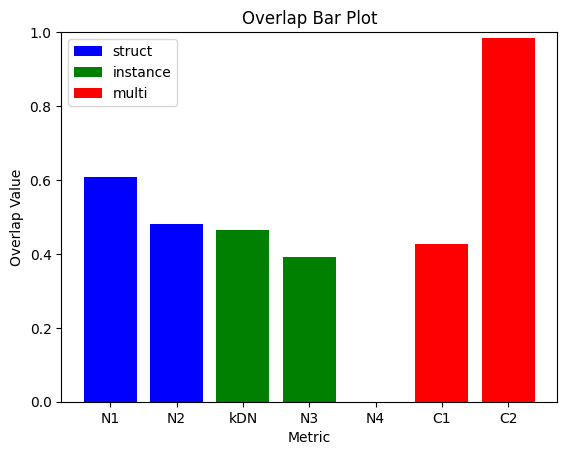

--- Calcolo Complessità | Metodo: SPATIAL ---
Strategia: Media Spaziale (Tutti i canali)
Dataset ridotto per complessità: (28, 128)
Calcolo metriche in corso...
Calcolo completato.

Visualizzazione Spatial Mean:
{'feature': {}, 'struct': {'N1': 0.5, 'N2': 0.46863520566589906}, 'instance': {'kDN': 0.45000000000000007, 'N3': 0.2857142857142857, 'N4': 0.07142857142857142}, 'multi': {'C1': 0.4001190476190476, 'C2': 1.0}}


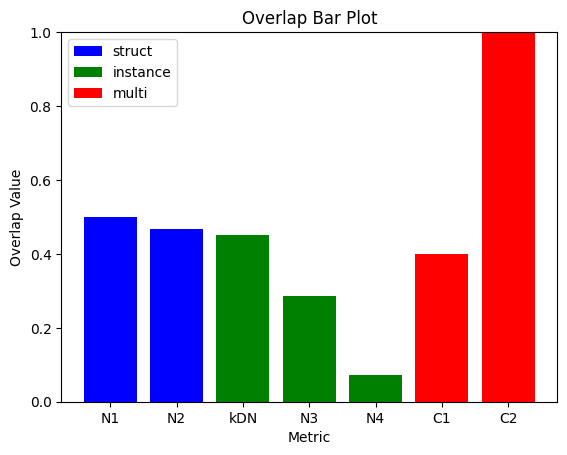

In [6]:
# ESEMPIO 1: Metodo PCA (come facevi prima)
comp_pca = calculate_complexity_metrics(
    X_res, y_res, 
    method='pca', 
    n_components=50, 
    subset_ratio=0.010, imb=False
)
print("Visualizzazione PCA:")
comp_pca.viz_metrics(imb=False)


# ESEMPIO 2: Metodo Spatial (Media di tutti i canali)
comp_spatial_mean = calculate_complexity_metrics(
    X_res, y_res , 
    method='spatial', 
    channel_idx=None, # None = media globale
    subset_ratio=0.010, imb=False
)
print("\nVisualizzazione Spatial Mean:")
comp_spatial_mean.viz_metrics(imb=False)

In [7]:
run_p300_classification(X_train_sess, y_train_sess, X_test_sess, y_test_sess, use_smote=True)


--- Avvio Classificazione (SMOTE: ON) ---
Bilanciamento completato: 1600 -> 2800 epoche
------------------------------
Accuracy Non-Target: 78.98%
Accuracy Target:     25.14%
------------------------------
              precision    recall  f1-score   support

  Non-Target       0.88      0.79      0.83      2450
      Target       0.15      0.25      0.18       350

    accuracy                           0.72      2800
   macro avg       0.51      0.52      0.51      2800
weighted avg       0.79      0.72      0.75      2800



(Pipeline(steps=[('xdawn', XdawnCovariances(estimator='oas')), ('mdm', MDM())]),
 array([0, 0, 0, ..., 0, 0, 0]))

In [8]:
run_p300_classification(X_train_sess, y_train_sess, X_test_sess, y_test_sess, use_smote=False)


--- Avvio Classificazione (SMOTE: OFF) ---
Utilizzo dati originali: 1600 epoche
------------------------------
Accuracy Non-Target: 84.69%
Accuracy Target:     58.29%
------------------------------
              precision    recall  f1-score   support

  Non-Target       0.93      0.85      0.89      2450
      Target       0.35      0.58      0.44       350

    accuracy                           0.81      2800
   macro avg       0.64      0.71      0.66      2800
weighted avg       0.86      0.81      0.83      2800



(Pipeline(steps=[('xdawn', XdawnCovariances(estimator='oas')), ('mdm', MDM())]),
 array([0, 1, 0, ..., 0, 1, 1]))

In [9]:
import torch
from torch.utils.data import TensorDataset
X_train_sess_smoted, y_train_sess_smoted = apply_smote_3d(X_train_sess, y_train_sess)

import torch
from torch.utils.data import TensorDataset

# 1. Conversione in Tensor
# Assicuriamoci che siano float (necessario per media e deviazione standard)
X_train_tensor = torch.tensor(X_train_sess_smoted).float()
y_train_tensor = torch.tensor(y_train_sess_smoted).long()

X_test_tensor = torch.tensor(X_test_sess).float()
y_test_tensor = torch.tensor(y_test_sess).long()

# 2. Reshape per EEGNet (Batch, 1, Canali, Tempo)
if X_train_tensor.ndim == 3:
    X_train_tensor = X_train_tensor.unsqueeze(1)
if X_test_tensor.ndim == 3:
    X_test_tensor = X_test_tensor.unsqueeze(1)

# 3. Calcolo di Media e Std (SOLO sul Training set)
# Calcoliamo la media su tutto il dataset di training per ogni punto (o globale)
# dim=0 calcola la media lungo la dimensione dei trial, preservando (1, Canali, Tempo)
train_mean = X_train_tensor.mean(dim=0, keepdim=True)
train_std = X_train_tensor.std(dim=0, keepdim=True)

# 4. Applicazione Z-Score (Standardizzazione)
# Aggiungiamo un piccolo epsilon (1e-8) per evitare divisioni per zero se la std è 0
X_train_norm = (X_train_tensor - train_mean) / (train_std)

# IMPORTANTE: Il test set si normalizza con la media/std del TRAINING set
X_test_norm = (X_test_tensor - train_mean) / (train_std)

# 5. Creazione dei Dataset
train_dataset = TensorDataset(X_train_norm, y_train_tensor)
test_dataset = TensorDataset(X_test_norm, y_test_tensor)

# Verifica
print(f"Forma del tensore di training: {train_dataset.tensors[0].shape}")
print(f"Forma del tensore di test: {test_dataset.tensors[0].shape}")

# Controllo rapido che la media sia vicina a 0 e std a 1 sul train
print(f"Mean Train dopo norm: {train_dataset.tensors[0].mean():.4f}")
print(f"Std Train dopo norm: {train_dataset.tensors[0].std():.4f}")

Bilanciamento completato: 1600 -> 2800 epoche
Forma del tensore di training: torch.Size([2800, 1, 8, 128])
Forma del tensore di test: torch.Size([2800, 1, 8, 128])
Mean Train dopo norm: -0.0000
Std Train dopo norm: 0.9998


In [10]:
X_all = train_dataset.tensors[0]
y_all = train_dataset.tensors[1]

# 2. Crea maschere booleane per separare le classi con certezza
mask_0 = (y_all == 0)
mask_1 = (y_all == 1)

# 3. Crea i dataset filtrati (PURI)
# Usiamo .clone() per sicurezza di memoria
real_0_ds = TensorDataset(X_all[mask_0].clone(), y_all[mask_0].clone())
real_1_ds = TensorDataset(X_all[mask_1].clone(), y_all[mask_1].clone())

# Se hai i dati fake (GAN), isolali allo stesso modo se necessario, 
# oppure usa quelli che avevi già preparato se sei sicuro siano solo Classe 1.
# fake_1_ds = ... 

print(f"VERIFICADataset:")
print(f" - Classe 0 pura: {len(real_0_ds)} campioni")
print(f" - Classe 1 pura (Reali): {len(real_1_ds)} campioni")

VERIFICADataset:
 - Classe 0 pura: 1400 campioni
 - Classe 1 pura (Reali): 1400 campioni


MODE: Batch Bilanciato Reale (Oversampling C1 se necessario)
Composizione Batch: C0=32, C1_Real=32, C1_Fake=0


/home/giorgio99/miniconda3/envs/eeg_research/lib/python3.11/site-packages/torch/nn/modules/conv.py:456: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at ../aten/src/ATen/native/Convolution.cpp:1031.)
  return F.conv2d(input, weight, bias, self.stride,


Epoch 1/300, Loss: 0.6575, Accuracy: 60.65%
Epoch 2/300, Loss: 0.5923, Accuracy: 70.89%
Epoch 3/300, Loss: 0.5268, Accuracy: 75.76%
Epoch 4/300, Loss: 0.4904, Accuracy: 77.40%
Epoch 5/300, Loss: 0.4468, Accuracy: 79.54%
Epoch 6/300, Loss: 0.4352, Accuracy: 80.34%
Epoch 7/300, Loss: 0.4089, Accuracy: 81.72%
Epoch 8/300, Loss: 0.3904, Accuracy: 83.18%
Epoch 9/300, Loss: 0.3909, Accuracy: 83.14%
Epoch 10/300, Loss: 0.3764, Accuracy: 84.27%
Epoch 11/300, Loss: 0.3716, Accuracy: 84.59%
Epoch 12/300, Loss: 0.3769, Accuracy: 84.05%
Epoch 13/300, Loss: 0.3592, Accuracy: 84.88%
Epoch 14/300, Loss: 0.3650, Accuracy: 84.81%
Epoch 15/300, Loss: 0.3611, Accuracy: 84.52%
Epoch 16/300, Loss: 0.3516, Accuracy: 85.25%
Epoch 17/300, Loss: 0.3421, Accuracy: 85.47%
Epoch 18/300, Loss: 0.3440, Accuracy: 85.28%
Epoch 19/300, Loss: 0.3315, Accuracy: 86.52%
Epoch 20/300, Loss: 0.3207, Accuracy: 87.17%
Epoch 21/300, Loss: 0.3357, Accuracy: 86.16%
Epoch 22/300, Loss: 0.3315, Accuracy: 86.66%
Epoch 23/300, Loss:

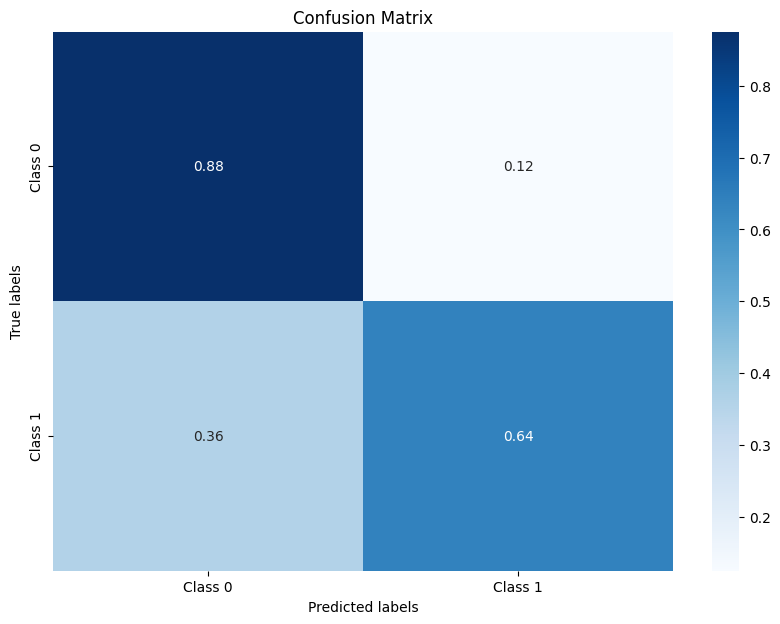

In [11]:
# --- CONFIGURAZIONE ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CHANS = X_train_sess.shape[1]      # es: 22
TIME_POINTS = X_train_sess.shape[2] # es: 1001
CLASSES = len(np.unique(y_train_sess)) # es: 4

# 1. Inizializza il Modello
model = EEGNetModel(
    chans=CHANS, 
    classes=CLASSES, 
    time_points=TIME_POINTS
).to(device)

# 2. Allena il Modello (Classe TrainModel)
trainer = TrainModel()
# Nota: train_model restituisce il modello allenato e lo salva come 'eegnet_model.pth'
trained_eegnet_model = trainer.train_model(
    model, 
    real_0_ds, 
    real_1_ds, 
    train_dataset, 
    learning_rate=0.001, 
    batch_size=64, 
    epochs=300,# Puoi aumentare a 500 se vedi che la loss scende ancora
     fake_ratio_in_c1=0.0 
)

# 3. Testa il Modello (Classe EvalModel)
evaluator = EvalModel(trained_eegnet_model)
test_acc = evaluator.test_model(test_dataset)

# 4. Visualizza i risultati (Confusion Matrix)
# Definisci i nomi delle classi per il grafico
class_names = [f"Class {i}" for i in range(CLASSES)] 
evaluator.plot_confusion_matrix(test_dataset, classes=class_names)

In [12]:
import sys
import os

percorso_gan = "/home/giorgio99/gan_bci/EEG-GAN-main/EEG_GAN_main/eeggan"

if percorso_gan not in sys.path:
    sys.path.append(percorso_gan)

from eeggan.helpers import system_inputs
from eeggan.gan_training_main import main as train_gan

In [13]:
import pandas as pd
import numpy as np
import torch
import os

def save_to_eeg_csv(X, y, subject_ids, session_ids, filename):
    """
    Converte i tensori EEG in formato CSV compatibile con il tutorial.
    """
    n_trials, n_channels, n_times = X.shape
    
    # Appiattiamo i dati del segnale
    data_flat = X.reshape(-1, n_times)
    if isinstance(data_flat, torch.Tensor):
        data_flat = data_flat.numpy()

    # Preparazione colonne comuni
    condition_col = np.repeat(y if isinstance(y, np.ndarray) else y.numpy(), n_channels)
    trial_col = np.repeat(np.arange(1, n_trials + 1), n_channels)
    electrode_col = np.tile(np.arange(1, n_channels + 1), n_trials)
    
    # Metadati ID
    unique_subjs = np.unique(subject_ids)
    participant_col_raw = np.repeat(subject_ids, n_channels)
    session_col_raw = np.repeat(session_ids, n_channels)

    meta_data = {}
    # Logica ID: se c'è più di un soggetto usa ParticipantID, altrimenti SessionID
    if len(unique_subjs) > 1:
        meta_data['ParticipantID'] = participant_col_raw
    else:
        meta_data['ParticipantID'] = session_col_raw

    meta_data['Condition'] = condition_col
    meta_data['Trial'] = trial_col
    meta_data['Electrode'] = electrode_col

    # Assemblaggio
    df_meta = pd.DataFrame(meta_data)
    time_cols = [f'Time{i}' for i in range(1, n_times + 1)]
    df_data = pd.DataFrame(data_flat, columns=time_cols)
    df = pd.concat([df_meta, df_data], axis=1)

    # Salvataggio
    df.to_csv(filename, index=False)
    print(f"File salvato: {filename} | Shape: {df.shape}")

# --- ESECUZIONE ---

# Salva il Training Set
save_to_eeg_csv(X_train_sess, y_train_sess, subjects_train_ids, session_train_ids, 'dataset_eeg_train_3_subj_3_sess.csv')

# Salva il Test Set (Il file che ti serve per il codice del tutorial)
save_to_eeg_csv(X_test_sess, y_test_sess, subjects_test_ids, session_test_ids, 'dataset_eeg_test_3_subj_3_sess.csv')

File salvato: dataset_eeg_train_3_subj_3_sess.csv | Shape: (12800, 132)
File salvato: dataset_eeg_test_3_subj_3_sess.csv | Shape: (22400, 132)


In [14]:
import pandas as pd
import torch
import numpy as np
import os

def load_balanced_synthetic_limited(path_c0, path_c1, max_trials=1200):
    """
    Carica esplicitamente i primi 'max_trials' per classe 0 e classe 1.
    """
    # Calcoliamo quante righe leggere (8 righe per ogni trial)
    rows_to_read = max_trials * 8

    def get_data_from_csv(path):
        if not os.path.exists(path):
            print(f"ERRORE: File non trovato {path}")
            return None, None
        
        # Leggiamo solo le righe necessarie con nrows
        df = pd.read_csv(path, nrows=rows_to_read)
        
        # Prendiamo le colonne Time
        time_cols = [col for col in df.columns if col.startswith('Time')]
        X = df[time_cols].values
        y = df['Condition'].values
        return X, y

    # Carichiamo i due blocchi limitati
    print(f"Caricamento primi {max_trials} trial Classe 0...")
    X0_rows, y0_rows = get_data_from_csv(path_c0)
    
    print(f"Caricamento primi {max_trials} trial Classe 1...")
    X1_rows, y1_rows = get_data_from_csv(path_c1)

    # Conversione in Tensor e Raggruppamento
    # Se abbiamo letto 68800 righe, diventano 8600 trial da 8 elettrodi
    X0_trial = torch.tensor(X0_rows).view(-1, 8, 128)
    y0_trial = torch.tensor(y0_rows[::8]) 
    
    X1_trial = torch.tensor(X1_rows).view(-1, 8, 128)
    y1_trial = torch.tensor(y1_rows[::8])

    return X0_trial, y0_trial, X1_trial, y1_trial

# --- ESECUZIONE ---
file_c0 = 'generated_samples/aegan_w_lae_data_c0_subj_3_sess_3.csv'
file_c1 = 'generated_samples/aegan_w_lae_data_c1_subj_3_sess_3.csv'

# Carichiamo solo 8600 trials per classe
X0_syn, y0_syn, X1_syn, y1_syn = load_balanced_synthetic_limited(file_c0, file_c1, max_trials=8600)

print("-" * 30)
print(f"Trial caricate Classe 0: {X0_syn.shape[0]} (Labels: {y0_syn.shape[0]})")
print(f"Trial caricate Classe 1: {X1_syn.shape[0]} (Labels: {y1_syn.shape[0]})")

Caricamento primi 8600 trial Classe 0...
Caricamento primi 8600 trial Classe 1...
------------------------------
Trial caricate Classe 0: 1200 (Labels: 1200)
Trial caricate Classe 1: 1200 (Labels: 1200)


In [15]:
import torch

# 1. Concatena i dati (che sono già in formato TRIAL [1200, 8, 128])
X_syn_final = torch.cat([X0_syn, X1_syn], dim=0) # Diventa [2400, 8, 128]
y_syn_final = torch.cat([y0_syn, y1_syn], dim=0) # Diventa [2400]

# Non serve altro! I dati sono già accoppiati 1 a 1.
print(f"Forma finale SINTETICI: X={X_syn_final.shape}, y={y_syn_final.shape}")

Forma finale SINTETICI: X=torch.Size([2400, 8, 128]), y=torch.Size([2400])


In [16]:
from scipy import signal
# --- 2. FILTRAGGIO E PREPARAZIONE FAKE ---
def lowpass_filter(data, fs=128):
    b, a = signal.butter(4, 15.0, btype='low', fs=fs)
    return signal.filtfilt(b, a, data, axis=-1)
X_syn_np = X_syn_final.cpu().numpy()

# 3. Applicazione del filtraggio
# Usiamo axis=-1 perché i 128 punti temporali sono nell'ultima dimensione
X_syn_filtered_np = lowpass_filter(X_syn_np, fs=128)

# 4. Riconversione in Tensore PyTorch
# .copy() previene l'errore di "negative strides", .float() garantisce 32-bit
X_syn_filtered = torch.tensor(X_syn_filtered_np.copy()).float()

print(f"Filtraggio completato.")
print(f"Forma originale: {X_syn_final.shape}")
print(f"Forma dopo filtro: {X_syn_filtered.shape}")

Filtraggio completato.
Forma originale: torch.Size([2400, 8, 128])
Forma dopo filtro: torch.Size([2400, 8, 128])


In [17]:
X_grouped_perm = X_syn_filtered.permute(0, 2, 1) 

# 2. Separa i trial sintetici usando le etichette corrette (0.0 per Win, 1.0 per Loss)
syn_win = X_grouped_perm[y_syn_final == 0.0]
syn_loss = X_grouped_perm[y_syn_final == 1.0]

# 3. Verifica finale delle dimensioni
print(f"Sintetici Win: {syn_win.shape}, Loss: {syn_loss.shape}")

Sintetici Win: torch.Size([1200, 128, 8]), Loss: torch.Size([1200, 128, 8])


In [18]:
import torch
import numpy as np

X_train_tensor = torch.tensor(X_train_sess).float()
y_train_tensor = torch.tensor(y_train_sess).float()
X_test_sess_tensor = torch.tensor(X_test_sess).float()
y_test_sess_tensor = torch.tensor(y_test_sess).float()
# 1. Calcola Media e Deviazione Standard dal TRAIN REALE (µV)
# Li usiamo come riferimento per tutto
mu_ref = X_train_tensor.mean()
std_ref = X_train_tensor.std()

# 2. Trasforma i Reali in Z-score (per farli digerire all'Encoder)
X_train_real_z = (X_train_tensor - mu_ref) / (std_ref)
X_test_real_z  = (X_test_sess_tensor - mu_ref) / (std_ref) # Carica il test allo stesso modo

# 3. Allinea le dimensioni a [Batch, Tempo, Canali] -> [N, 128, 8]
# Se i tuoi tensori sono [N, 8, 128], dobbiamo permutarli
X_train_real_ready = X_train_real_z.permute(0, 2, 1)
X_test_real_ready  = X_test_real_z.permute(0, 2, 1)

print(f"Reali pronti: Train {X_train_real_ready.shape}, Test {X_test_real_ready.shape}")

Reali pronti: Train torch.Size([1600, 128, 8]), Test torch.Size([2800, 128, 8])


In [19]:
# --- CLASSE 0 (WIN) ---
real_train_0 = X_train_real_ready[y_train_tensor == 0]
real_test_0  = X_test_real_ready[y_test_sess_tensor == 0]
# syn_win lo hai già creato tu ed è [N, 128, 8]

# --- CLASSE 1 (LOSS) ---
real_train_1 = X_train_real_ready[y_train_tensor == 1]
real_test_1  = X_test_real_ready[y_test_sess_tensor == 1]
# syn_loss lo hai già creato tu ed è [N, 128, 8]

In [20]:
import torch
import numpy as np
from scipy import linalg

def calculate_fid_eeg(real_data, syn_data, encoder, device='cuda'):
    """
    Calcola il FID usando l'Encoder del progetto come estrattore di feature.
    
    real_data: Tensor [N, Time, Channels] (Dati reali filtrati e Z-scored)
    syn_data:  Tensor [N, Time, Channels] (Dati sintetici filtrati e Z-scored)
    encoder:   Il tuo modello TransformerAutoencoder (già caricato)
    """
    encoder.to(device)
    encoder.eval()

    def get_features(data):
        with torch.no_grad():
            if isinstance(data, np.ndarray):
                data = torch.from_numpy(data).float()
            data = data.to(device).float()
            # Passiamo i dati nell'encoder
            feat = encoder.encode(data.to(device))
            
            # Appiattiamo le feature (Batch, Seq, Feat) -> (Batch, Seq*Feat)
            feat = feat.reshape(feat.shape[0], -1).cpu().numpy()
        return feat

    # 1. Estrazione delle feature latenti
    act1 = get_features(real_data)
    act2 = get_features(syn_data)
    print(act1.shape, act2.shape) # Debug: verifica dimensioni feature  
    # 2. Calcolo media e covarianza
    mu1, sigma1 = act1.mean(axis=0), np.cov(act1, rowvar=False)
    mu2, sigma2 = act2.mean(axis=0), np.cov(act2, rowvar=False)

    # 3. Calcolo della distanza di Fréchet
    # Formula: ||mu1 - mu2||^2 + Tr(sigma1 + sigma2 - 2*sqrt(sigma1*sigma2))
    diff = mu1 - mu2

    # Calcolo della radice quadrata del prodotto delle covarianze
    offset = np.eye(sigma1.shape[0]) * 1e-6 # Per stabilità numerica
    covmean, _ = linalg.sqrtm((sigma1 + offset).dot(sigma2 + offset), disp=False)
    
    if np.iscomplexobj(covmean):
        covmean = covmean.real

    tr_covmean = np.trace(covmean)

    fid = diff.dot(diff) + np.trace(sigma1) + np.trace(sigma2) - 2 * tr_covmean
    return fid

In [21]:

from eeggan.nn_architecture.ae_networks import TransformerAutoencoder
# 1. Carica il file (che è un dizionario/checkpoint)
# Definizione delle costanti della libreria eeggan
TARGET_CHANNELS = 0
TARGET_TIMESERIES = 1

# 1. Carica il checkpoint
checkpoint = torch.load('trained_ae/my_autoencoder_subj_3_all_sess.pt', map_location='cpu')
config = checkpoint['configuration']

# 2. Mappatura del target (da stringa a intero se necessario)
target_value = config['target']
if target_value == 'time':
    target_value = TARGET_TIMESERIES
elif target_value == 'channels':
    target_value = TARGET_CHANNELS

# 3. Inizializzazione del modello con i valori corretti
ae_model = TransformerAutoencoder(
    input_dim=config['input_dim'],
    output_dim=config['output_dim'],
    output_dim_2=config['output_dim_2'],
    target=target_value, # Qui deve esserci l'intero 1
    hidden_dim=config['hidden_dim'],
    num_layers=config['num_layers'],
    num_heads=config['num_heads']
)

# 4. Caricamento pesi
ae_model.load_state_dict(checkpoint['model'])
ae_model.eval()

# 5. Forziamo le costanti all'interno dell'oggetto per sicurezza
ae_model.TARGET_TIMESERIES = TARGET_TIMESERIES
ae_model.TARGET_CHANNELS = TARGET_CHANNELS

print(f"Modello pronto. Target impostato su: {ae_model.target} (Deve essere 1)")

Modello pronto. Target impostato su: 1 (Deve essere 1)


In [22]:
from scipy import linalg, stats, signal
def calculate_eeg_stats(real_tensor, syn_tensor, fs=128):
    # Convertiamo in numpy per le statistiche standard
    r = real_tensor.cpu().numpy()
    s = syn_tensor.cpu().numpy()
    
    # Pearson CC (sulle medie dei trial)
    ga_r, ga_s = np.mean(r, axis=0), np.mean(s, axis=0)
    corrs = [np.corrcoef(ga_r[:, ch], ga_s[:, ch])[0, 1] for ch in range(r.shape[2])]
    avg_cc = np.mean(corrs)

    # Wasserstein Distance (sulle ampiezze flat)
    wd = stats.wasserstein_distance(r.flatten(), s.flatten())

    # Spectral Similarity (correlazione delle PSD medie)
    psd_corrs = []
    for ch in range(r.shape[2]):
        _, p_r = signal.welch(r[:, :, ch], fs=fs, axis=1)
        _, p_s = signal.welch(s[:, :, ch], fs=fs, axis=1)
        psd_corrs.append(np.corrcoef(np.mean(p_r, 0), np.mean(p_s, 0))[0, 1])
    avg_psd = np.mean(psd_corrs)

    return {"Pearson_CC": avg_cc, "Wasserstein_Dist": wd, "Spectral_Sim": avg_psd}

# --- 3. ESECUZIONE ANALISI INCROCIATA ---
comparisons = [
    ("Syn vs Train", "Sintetici", "Real Train"),
    ("Syn vs Test",  "Sintetici", "Real Test"),
    ("Benchmark",    "Real Test", "Real Train")
]

# Struttura per i risultati
results = {comp[0]: {"Win": {}, "Loss": {}} for comp in comparisons}

# Funzione helper per popolare i dati
def run_full_comparison(comp_name, data_a, data_b, cls_name):
    # Calcolo FID (richiede i tensori)
    fid = calculate_fid_eeg(data_a, data_b, ae_model)
    # Calcolo altre metriche
    other_metrics = calculate_eeg_stats(data_a, data_b)
    
    results[comp_name][cls_name]["FID"] = fid
    results[comp_name][cls_name].update(other_metrics)

# ESECUZIONE PER CLASSE 0 (WIN)
run_full_comparison("Syn vs Train", real_train_0, syn_win, "Win")
run_full_comparison("Syn vs Test",  real_test_0,  syn_win, "Win")
run_full_comparison("Benchmark",    real_train_0, real_test_0, "Win")

# ESECUZIONE PER CLASSE 1 (LOSS)
run_full_comparison("Syn vs Train", real_train_1, syn_loss, "Loss")
run_full_comparison("Syn vs Test",  real_test_1,  syn_loss, "Loss")
run_full_comparison("Benchmark",    real_train_1, real_test_1, "Loss")

# --- 4. VISUALIZZAZIONE FINALE ---
metrics = ["FID", "Pearson_CC", "Wasserstein_Dist", "Spectral_Sim"]

print("\n" + "="*85)
print(f"{'CONFRONTO':<20} | {'METRICA':<18} | {'WIN (0)':<18} | {'LOSS (1)':<18}")
print("="*85)

for comp in [c[0] for c in comparisons]:
    for i, m in enumerate(metrics):
        row_label = comp if i == 0 else ""
        val_win = results[comp]["Win"][m]
        val_loss = results[comp]["Loss"][m]
        
        # Formattazione condizionale: FID e WD sono distanze (meno è meglio), CC e Spectral sono similarità (più è meglio)
        print(f"{row_label:<20} | {m:<18} | {val_win:>18.4f} | {val_loss:>18.4f}")
    print("-" * 85)

(1400, 512) (1200, 512)


/tmp/ipykernel_92629/4219445771.py:42: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = linalg.sqrtm((sigma1 + offset).dot(sigma2 + offset), disp=False)
/tmp/ipykernel_92629/3597128673.py:18: UserWarning: nperseg=256 is greater than signal length max(len(x), len(y)) = 128, using nperseg = 128
  _, p_r = signal.welch(r[:, :, ch], fs=fs, axis=1)
/tmp/ipykernel_92629/3597128673.py:19: UserWarning: nperseg=256 is greater than signal length max(len(x), len(y)) = 128, using nperseg = 128
  _, p_s = signal.welch(s[:, :, ch], fs=fs, axis=1)


(2450, 512) (1200, 512)
(1400, 512) (2450, 512)
(200, 512) (1200, 512)
(350, 512) (1200, 512)
(200, 512) (350, 512)

CONFRONTO            | METRICA            | WIN (0)            | LOSS (1)          
Syn vs Train         | FID                |             2.6822 |             2.7849
                     | Pearson_CC         |             0.0547 |             0.6838
                     | Wasserstein_Dist   |             0.0810 |             0.0691
                     | Spectral_Sim       |             0.9938 |             0.9908
-------------------------------------------------------------------------------------
Syn vs Test          | FID                |             2.6983 |             3.5858
                     | Pearson_CC         |             0.0713 |             0.5532
                     | Wasserstein_Dist   |             0.0558 |             0.0540
                     | Spectral_Sim       |             0.9901 |             0.9823
-----------------------------------------

In [23]:
import torch
import numpy as np
from torch.utils.data import TensorDataset

# --- 1. FUNZIONE DI NORMALIZZAZIONE PER SINGOLO TRIAL ---
def trial_wise_normalize(data):
    """
    Normalizza ogni trial indipendentemente: media 0, std 1.
    data shape: (N, 8, 128)
    """
    # Calcoliamo media e std lungo gli assi 1 (canali) e 2 (tempo) per ogni trial
    # Risultato ha forma (N, 1, 1)
    mu = data.mean(axis=(1,2), keepdims=True)
    std = data.std(axis=(1,2), keepdims=True)
    return (data - mu) / (std)

# --- 2. FILTRAGGIO E PREPARAZIONE FAKE ---
def lowpass_filter(data, fs=128):
    b, a = signal.butter(4, 15.0, btype='low', fs=fs)
    return signal.filtfilt(b, a, data, axis=-1)

# Prendi i sintetici (Z-score) e portali in forma (N, 8, 128)
X_fake_z = syn_loss[:8400].permute(0, 2, 1).cpu().numpy()
X_fake_filtered = lowpass_filter(X_fake_z)

# --- 3. APPLICA NORMALIZZAZIONE TRIAL-WISE A TUTTI ---
# Questo garantisce che Reali e Fake siano sulla STESSA SCALA statistica
X_train_real_norm = trial_wise_normalize(X_train_sess)
X_test_real_norm  = trial_wise_normalize(X_test_sess)
X_fake_norm       = trial_wise_normalize(X_fake_filtered)

# --- 4. CONCATENAZIONE ---
X_augmented = np.concatenate([X_train_real_norm, X_fake_norm], axis=0)
y_augmented = np.concatenate([
    y_train_sess, 
    np.ones(len(X_fake_norm))
], axis=0)

# --- 5. CONVERSIONE IN TENSORI PER EEGNET ---
X_train_t = torch.tensor(X_augmented.copy()).float().unsqueeze(1)
y_train_t = torch.tensor(y_augmented).long()

X_test_t = torch.tensor(X_test_real_norm.copy()).float().unsqueeze(1)
y_test_t = torch.tensor(y_test_sess).long()

train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

print(f"Bilanciamento Completato. Scala: Media {X_train_t.mean():.4f}, Std {X_train_t.std():.4f}")

Bilanciamento Completato. Scala: Media -0.0000, Std 1.0000


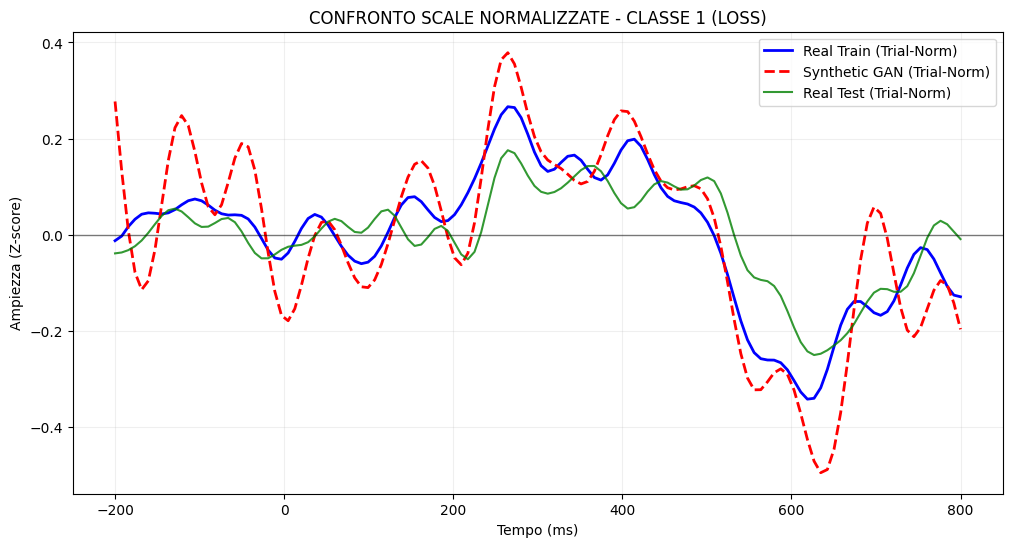

Max Ampiezza Real: 0.2663
Max Ampiezza GAN:  0.3786


In [24]:
import matplotlib.pyplot as plt

# --- VISUALIZZAZIONE SOLO CLASSE 1 (LOSS) SU DATI NORMALIZZATI ---

# 1. Estraiamo i trial normalizzati di classe 1
idx_train_c1 = np.where(y_train_sess == 1)[0]
X_real_c1_norm = X_train_real_norm[idx_train_c1]

idx_test_c1 = np.where(y_test_sess == 1)[0]
X_test_c1_norm = X_test_real_norm[idx_test_c1]

# I fake sono già tutti classe 1 e già normalizzati
X_fake_c1_norm = X_fake_norm

# 2. Calcoliamo le medie (Grand Average)
ga_real_train = np.mean(X_real_c1_norm, axis=(0, 1))
ga_fake_train = np.mean(X_fake_c1_norm, axis=(0, 1))
ga_real_test  = np.mean(X_test_c1_norm, axis=(0, 1))

# 3. Plot
plt.figure(figsize=(12, 6))
time_axis = np.linspace(-200, 800, 128)

plt.plot(time_axis, ga_real_train, label='Real Train (Trial-Norm)', color='blue', lw=2)
plt.plot(time_axis, ga_fake_train, label='Synthetic GAN (Trial-Norm)', color='red', lw=2, linestyle='--')
plt.plot(time_axis, ga_real_test,  label='Real Test (Trial-Norm)', color='green', lw=1.5, alpha=0.8)

plt.title("CONFRONTO SCALE NORMALIZZATE - CLASSE 1 (LOSS)")
plt.xlabel("Tempo (ms)")
plt.ylabel("Ampiezza (Z-score)")
plt.axhline(0, color='black', linewidth=1, alpha=0.5)
plt.grid(True, alpha=0.2)
plt.legend()
plt.show()

print(f"Max Ampiezza Real: {ga_real_train.max():.4f}")
print(f"Max Ampiezza GAN:  {ga_fake_train.max():.4f}")

In [25]:
from torch.utils.data import TensorDataset

# 1. Identifichiamo dove finiscono i dati reali e iniziano i fake
n_reali_totali = len(y_train_sess) # 11200 (9800 + 1400)

# 2. Scorporiamo i tensori reali dai sintetici
X_reali_all = X_train_t[:n_reali_totali]
y_reali_all = y_train_t[:n_reali_totali]

X_fake_all = X_train_t[n_reali_totali:]
y_fake_all = y_train_t[n_reali_totali:]

# 3. Creiamo le maschere per separare le classi REALI
mask_0 = (y_reali_all == 0)
mask_1 = (y_reali_all == 1)

# 4. Creiamo i 3 Dataset indipendenti
real_0_ds = TensorDataset(X_reali_all[mask_0].clone(), y_reali_all[mask_0].clone())
real_1_ds = TensorDataset(X_reali_all[mask_1].clone(), y_reali_all[mask_1].clone())
fake_1_ds = TensorDataset(X_fake_all.clone(), y_fake_all.clone())

print(f"Dataset pronti:")
print(f" - Real Classe 0: {len(real_0_ds)}")
print(f" - Real Classe 1: {len(real_1_ds)}")
print(f" - Fake Classe 1: {len(fake_1_ds)}")

Dataset pronti:
 - Real Classe 0: 1400
 - Real Classe 1: 200
 - Fake Classe 1: 1200


MODE: Data Augmentation GAN (Ratio Fake in C1: 0.5)
Composizione Batch: C0=32, C1_Real=16, C1_Fake=16
Epoch 1/300, Loss: 0.6399, Accuracy: 62.65%
Epoch 2/300, Loss: 0.5705, Accuracy: 71.40%
Epoch 3/300, Loss: 0.5422, Accuracy: 72.46%
Epoch 4/300, Loss: 0.5256, Accuracy: 74.38%
Epoch 5/300, Loss: 0.4978, Accuracy: 76.09%
Epoch 6/300, Loss: 0.4868, Accuracy: 76.53%
Epoch 7/300, Loss: 0.4605, Accuracy: 78.38%
Epoch 8/300, Loss: 0.4543, Accuracy: 78.34%
Epoch 9/300, Loss: 0.4435, Accuracy: 79.29%
Epoch 10/300, Loss: 0.4358, Accuracy: 79.14%
Epoch 11/300, Loss: 0.4343, Accuracy: 80.20%
Epoch 12/300, Loss: 0.4118, Accuracy: 81.29%
Epoch 13/300, Loss: 0.4064, Accuracy: 80.81%
Epoch 14/300, Loss: 0.4167, Accuracy: 80.74%
Epoch 15/300, Loss: 0.4023, Accuracy: 81.25%
Epoch 16/300, Loss: 0.3857, Accuracy: 82.38%
Epoch 17/300, Loss: 0.3894, Accuracy: 81.69%
Epoch 18/300, Loss: 0.3834, Accuracy: 82.99%
Epoch 19/300, Loss: 0.3642, Accuracy: 83.58%
Epoch 20/300, Loss: 0.3787, Accuracy: 82.74%
Epoch 2

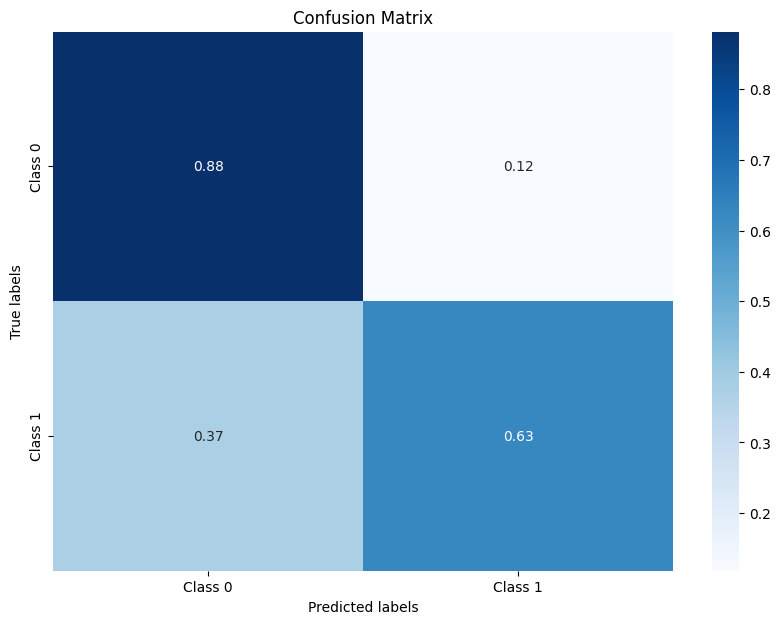

In [26]:
# --- CONFIGURAZIONE ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CHANS = X_train_sess.shape[1]      # es: 22
TIME_POINTS = X_train_sess.shape[2] # es: 1001
CLASSES = len(np.unique(y_train_sess)) # es: 4

# 1. Inizializza il Modello
model = EEGNetModel(
    chans=CHANS, 
    classes=CLASSES, 
    time_points=TIME_POINTS
).to(device)

# 2. Allena il Modello (Classe TrainModel)
trainer = TrainModel()
# Nota: train_model restituisce il modello allenato e lo salva come 'eegnet_model.pth'
trained_eegnet_model = trainer.train_model(
    model, 
    real_0_ds, 
    real_1_ds, 
    fake_1_ds=fake_1_ds,
    learning_rate=0.001, 
    batch_size=64, 
    epochs=300, # Puoi aumentare a 500 se vedi che la loss scende ancora
    fake_ratio_in_c1=0.5
)

# 3. Testa il Modello (Classe EvalModel)
evaluator = EvalModel(trained_eegnet_model)
test_acc = evaluator.test_model(test_dataset)

# 4. Visualizza i risultati (Confusion Matrix)
# Definisci i nomi delle classi per il grafico
class_names = [f"Class {i}" for i in range(CLASSES)] 
evaluator.plot_confusion_matrix(test_dataset, classes=class_names)

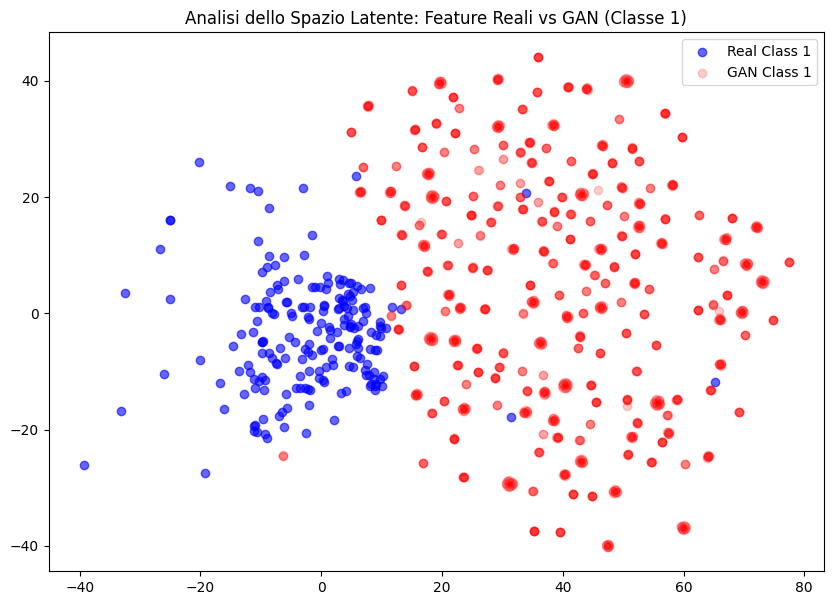

In [28]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

def plot_embedding_analysis(model, train_dataset, num_real_samples):
    model.eval()
    features = []
    labels = []
    sources = [] 

    with torch.no_grad():
        for i in range(len(train_dataset)):
            x, y = train_dataset[i]
            x = x.unsqueeze(0).to(device)
            
            feat = model.block1(x)
            feat = model.block2(feat)
            feat = model.block3(feat)
            feat = model.flatten(feat)
            
            features.append(feat.cpu().numpy())
            labels.append(y.item())
            
            # --- FIX: Usa la variabile passata alla funzione ---
            sources.append(0 if i < num_real_samples else 1) 
    features = np.concatenate(features)
    
    # Riduciamo a 2D con t-SNE
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    embedded = tsne.fit_transform(features)

    # Plot
    plt.figure(figsize=(10, 7))
    # Filtriamo solo la CLASSE 1 (quella aumentata)
    idx_c1 = np.where(np.array(labels) == 1)[0]
    
    plt.scatter(embedded[idx_c1, 0][np.array(sources)[idx_c1] == 0], 
                embedded[idx_c1, 1][np.array(sources)[idx_c1] == 0], 
                label='Real Class 1', alpha=0.6, c='blue')
    
    plt.scatter(embedded[idx_c1, 0][np.array(sources)[idx_c1] == 1], 
                embedded[idx_c1, 1][np.array(sources)[idx_c1] == 1], 
                label='GAN Class 1', alpha=0.2, c='red')
    
    plt.title("Analisi dello Spazio Latente: Feature Reali vs GAN (Classe 1)")
    plt.legend()
    plt.show()

plot_embedding_analysis(trained_eegnet_model, train_dataset, num_real_samples=len(real_0_ds) + len(real_1_ds))